## r/bakeoff subreddit analysis
This notebook analyzes what people are posting on the r/bakeoff subreddit, through the lens of GBBO episode technical challenges and air dates.

Hypothesis: After a GBBO episode airs, more people are bakeoff based off of that week's Technical Challenge.

The starting data for analysis is 'GBBO_bakeoff_reddit_posts_merged.csv'

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import re
from scipy import stats

In [2]:
#load the data

reddit_bakeoff_all_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/bakeoff_reddit_data_complete.csv')

reddit_bakeoff_gbbo_tech_posts = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/GBBO_bakeoff_reddit_posts_merged.csv')

In [3]:
dated_reddit_csv = Path("/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/reddit_bakeoff_all_posts_dated.csv")
if dated_reddit_csv.is_file():
    reddit_bakeoff_all_posts_dated = pd.read_csv(dated_reddit_csv)
    print(f"file already exists")
else:
    reddit_bakeoff_all_posts['date'] = pd.to_datetime(reddit_bakeoff_all_posts['created_utc'], unit='s')
    reddit_bakeoff_all_posts['date'] = reddit_bakeoff_all_posts['date'].dt.strftime('%m/%d/%Y')
    reddit_bakeoff_all_posts_dated = reddit_bakeoff_all_posts.drop(columns=['created_utc', 'Unnamed: 0'])

    reddit_bakeoff_all_posts_dated.to_csv('reddit_bakeoff_all_posts_dated.csv')

file already exists


In [4]:
#calculating denominator for normalization - how many posts are there per day in the r/bakeoff subreddit
r_bakeoff_post_counts = reddit_bakeoff_all_posts_dated['date'].value_counts().to_frame()
r_bakeoff_post_counts = r_bakeoff_post_counts.reset_index()
r_bakeoff_post_counts.to_csv('r_bakeoff_total_post_counts.csv')
r_bakeoff_post_counts

,date,count
0,11/28/2023,131
1,11/22/2020,73
2,11/24/2020,34
3,11/21/2020,28
4,11/27/2020,26
...,...,...
2460,06/26/2026,1
2461,06/27/2026,1
2462,07/13/2026,1
2463,07/14/2026,1


In [5]:
#force into dt
reddit_bakeoff_gbbo_tech_posts['reddit_post_date'] = pd.to_datetime(
    reddit_bakeoff_gbbo_tech_posts['reddit_post_date'], format='%Y-%m-%d'
)

r_bakeoff_post_counts['date'] = pd.to_datetime(
    r_bakeoff_post_counts['date'], format='%m/%d/%Y'
)

reddit_bakeoff_all_posts_dated['date'] = pd.to_datetime(
    reddit_bakeoff_all_posts_dated['date'], format='%m/%d/%Y'
)

In [6]:
# full set of dates and full set of technicals
all_dates = reddit_bakeoff_all_posts_dated['date'].unique()
all_technicals = reddit_bakeoff_gbbo_tech_posts['Technical'].unique()

# cross join to get every date x every technical combination
full_grid = pd.MultiIndex.from_product(
    [all_dates, all_technicals],
    names=['reddit_post_date', 'Technical']
).to_frame(index=False)

# actual counts
r_bakeoff_technical_post_counts = (
    reddit_bakeoff_gbbo_tech_posts
    .groupby(['reddit_post_date', 'Technical'])
    .size()
    .reset_index(name='post_count')
)

# left-merge onto the full grid, filling missing combos with 0
r_bakeoff_technical_post_counts = full_grid.merge(
    r_bakeoff_technical_post_counts,
    on=['reddit_post_date', 'Technical'],
    how='left'
)
r_bakeoff_technical_post_counts['post_count'] = r_bakeoff_technical_post_counts['post_count'].fillna(0).astype(int)

# now bring Airdate back in
r_bakeoff_technical_post_counts = r_bakeoff_technical_post_counts.merge(
    reddit_bakeoff_gbbo_tech_posts[['Technical', 'Airdate']].drop_duplicates(),
    on='Technical',
    how='left'
)
r_bakeoff_technical_post_counts.to_csv('r_bakeoff_technical_post_counts.csv')
r_bakeoff_technical_post_counts

,reddit_post_date,Technical,post_count,Airdate
0,2014-08-07,viennese whirls,0,2016-08-31
1,2014-08-07,dampfnudel,0,2016-09-07
2,2014-08-07,jumbles,0,2016-10-12
3,2014-08-07,fondant fancies,0,2012-10-16
4,2014-08-07,eight-strand plaited loaf,0,2012-08-21
...,...,...,...,...
46830,2026-07-19,malt loaf,0,2021-09-21
46831,2026-07-19,orange and ginger treacle puddings,0,2023-11-07
46832,2026-07-19,tart aux pommes,0,2023-11-21
46833,2026-07-19,vegan sausage rolls,0,2021-11-09


In [7]:
technical_full = r_bakeoff_technical_post_counts.merge(
    r_bakeoff_post_counts[['date', 'count']],
    left_on= 'reddit_post_date',
    right_on= 'date',
    how='left'
)

technical_full.to_csv('complete-r_bakeoff_post_counts.csv')
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count
0,2014-08-07,viennese whirls,0,2016-08-31,2014-08-07,2
1,2014-08-07,dampfnudel,0,2016-09-07,2014-08-07,2
2,2014-08-07,jumbles,0,2016-10-12,2014-08-07,2
3,2014-08-07,fondant fancies,0,2012-10-16,2014-08-07,2
4,2014-08-07,eight-strand plaited loaf,0,2012-08-21,2014-08-07,2
...,...,...,...,...,...,...
46830,2026-07-19,malt loaf,0,2021-09-21,2026-07-19,1
46831,2026-07-19,orange and ginger treacle puddings,0,2023-11-07,2026-07-19,1
46832,2026-07-19,tart aux pommes,0,2023-11-21,2026-07-19,1
46833,2026-07-19,vegan sausage rolls,0,2021-11-09,2026-07-19,1


In [8]:
#force into dt
technical_full['reddit_post_date'] = pd.to_datetime(
    technical_full['reddit_post_date'], format='%Y-%m-%d'
)

technical_full['Airdate'] = pd.to_datetime(
    technical_full['Airdate'], format='%Y-%m-%d'
)

technical_full['share'] = technical_full['post_count']/technical_full['count']
technical_full['days_since_air'] = (technical_full['reddit_post_date'] - technical_full['Airdate']).dt.days
technical_full

,reddit_post_date,Technical,post_count,Airdate,date,count,share,days_since_air
0,2014-08-07,viennese whirls,0,2016-08-31,2014-08-07,2,0.0,-755
1,2014-08-07,dampfnudel,0,2016-09-07,2014-08-07,2,0.0,-762
2,2014-08-07,jumbles,0,2016-10-12,2014-08-07,2,0.0,-797
3,2014-08-07,fondant fancies,0,2012-10-16,2014-08-07,2,0.0,660
4,2014-08-07,eight-strand plaited loaf,0,2012-08-21,2014-08-07,2,0.0,716
...,...,...,...,...,...,...,...,...
46830,2026-07-19,malt loaf,0,2021-09-21,2026-07-19,1,0.0,1762
46831,2026-07-19,orange and ginger treacle puddings,0,2023-11-07,2026-07-19,1,0.0,985
46832,2026-07-19,tart aux pommes,0,2023-11-21,2026-07-19,1,0.0,971
46833,2026-07-19,vegan sausage rolls,0,2021-11-09,2026-07-19,1,0.0,1713


In [9]:
technical_spread = (
    technical_full[technical_full['post_count'] > 0]
    .groupby('Technical')
    .agg(
        total_mentions=('post_count', 'sum'),
        pct_near_air=('days_since_air', lambda x: (x.abs() <= 21).mean())
    )
    .reset_index()
    .sort_values('pct_near_air')
)

technical_spread

,Technical,total_mentions,pct_near_air
0,chocolate teacakes,1,0.0
16,red velvet cake,1,0.0
15,queen of puddings,1,0.0
12,lemon meringue pie,1,0.0
11,eight-strand plaited loaf,1,0.0
8,æbleskiver,1,0.0
9,caterpiller cake,1,0.0
5,tuiles,1,0.0
1,fondant fancies,1,0.0
6,vegan sausage rolls,1,0.0


In [10]:
#note: dfs should have Technical, days_since_air, share, count.
#returns per-technical baseline, post-air avg, lift (ratio), lift_diff(abs)
#flags zero-baseline technicals (wehre ratio can't be computed)

def compute_lift(df, min_mentions=0):
    df = df[df['count'] >= min_mentions].copy()

    baseline = (
        df[(df['days_since_air'] >= -30) & (df['days_since_air'] <= -1)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='baseline_share')
    )

    post_air = (
        df[(df['days_since_air'] >= 0) & (df['days_since_air'] <= 21)]
        .groupby('Technical')['share']
        .mean()
        .reset_index(name='post_air_share')
    )

    lift = baseline.merge(post_air, on='Technical', how='outer')

    # missing from baseline or post_air entirely = no rows in that window = 0 activity, not missing data
    lift['baseline_share'] = lift['baseline_share'].fillna(0)
    lift['post_air_share'] = lift['post_air_share'].fillna(0)

    lift['lift_diff'] = lift['post_air_share'] - lift['baseline_share']

    return lift


def weekly_bucket_avg(df, window_days=90):
    """
    Buckets days_since_air into weekly bins and averages share across all technicals per bucket.
    Also returns per-bucket sample size (n pairs) so you can sanity-check reliability.
    """
    windowed = df[df['days_since_air'].abs() <= window_days].copy()
    windowed['week_bucket'] = windowed['days_since_air'] // 7

    weekly_avg = (
        windowed
        .groupby('week_bucket')['share']
        .mean()
        .reset_index()
        .sort_values('week_bucket')
    )

    weekly_counts = (
        windowed
        .groupby('week_bucket')
        .size()
        .reset_index(name='n_pairs')
    )

    weekly_avg = weekly_avg.merge(weekly_counts, on='week_bucket')

    return weekly_avg, windowed


bakeoff_lift = compute_lift(technical_full)

bakeoff_weekly, bakeoff_windowed = weekly_bucket_avg(technical_full)


In [11]:
bakeoff_lift.sort_values('lift_diff', ascending=False)
print(bakeoff_lift['lift_diff'].describe())
print((bakeoff_lift['post_air_share'] > 0).sum(), 'of', len(bakeoff_lift), 'technicals have nonzero post-air activity')
bakeoff_lift.to_csv('bakeoff_lift.csv', index=False)

count    14.000000
mean      0.007095
std       0.008990
min       0.000000
25%       0.000000
50%       0.003689
75%       0.010088
max       0.027778
Name: lift_diff, dtype: float64
8 of 14 technicals have nonzero post-air activity


In [12]:
#is post_air_share above 0 across technicals, more than just from random noise.
#looking for p-value < 0.5
#p=0.0117 - you'd see this pattern ~1 in 100 times by random chance alone
w_stat, w_p = stats.wilcoxon(bakeoff_lift['post_air_share'])
print(f"bakeoff post-air vs zero: W={w_stat:.3f}, p={w_p:.4f}")

bakeoff post-air vs zero: W=0.000, p=0.0117


In [14]:
baking_lift = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/baking_lift.csv')
bakeoff_lift = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/bakeoff_lift.csv')

print("r/baking lift_diff:")
print(baking_lift['lift_diff'].describe())
print(f"{(baking_lift['post_air_share'] > 0).sum()} of {len(baking_lift)} technicals have nonzero post-air activity")

print("\nr/bakeoff lift_diff:")
print(bakeoff_lift['lift_diff'].describe())
print(f"{(bakeoff_lift['post_air_share'] > 0).sum()} of {len(bakeoff_lift)} technicals have nonzero post-air activity")

w_stat_bakeoff, p_bakeoff = stats.wilcoxon(bakeoff_lift['post_air_share'])
print(f"\nr/bakeoff post-air vs 0: W={w_stat_bakeoff:.3f}, p={p_bakeoff:.4f}")

w_stat_baking, p_baking = stats.wilcoxon(baking_lift['post_air_share'], baking_lift['baseline_share'])
print(f"r/baking post-air vs baseline: W={w_stat_baking:.3f}, p={p_baking:.4f}")


#Mann-Whitney baking vs bakeoff
#<0.0001
#are these two subreddits behaving differentling from one another? - Yes.

u_stat, p_compare = stats.mannwhitneyu(
    bakeoff_lift['lift_diff'], baking_lift['lift_diff'], alternative='greater'
)
print(f"Mann-Whitney U (bakeoff > baking): U={u_stat:.3f}, p={p_compare:.4f}")

r/baking lift_diff:
count    67.000000
mean     -0.000006
std       0.000112
min      -0.000538
25%       0.000000
50%       0.000000
75%       0.000000
max       0.000310
Name: lift_diff, dtype: float64
3 of 67 technicals have nonzero post-air activity

r/bakeoff lift_diff:
count    14.000000
mean      0.007095
std       0.008990
min       0.000000
25%       0.000000
50%       0.003689
75%       0.010088
max       0.027778
Name: lift_diff, dtype: float64
8 of 14 technicals have nonzero post-air activity

r/bakeoff post-air vs 0: W=0.000, p=0.0117
r/baking post-air vs baseline: W=9.000, p=0.7532
Mann-Whitney U (bakeoff > baking): U=737.000, p=0.0000


In [15]:
results_summary = pd.DataFrame({
    'subreddit': ['r/baking', 'r/bakeoff'],
    'n_technicals': [len(baking_lift), len(bakeoff_lift)],
    'pct_nonzero_post_air': [
        (baking_lift['post_air_share'] > 0).mean() * 100,
        (bakeoff_lift['post_air_share'] > 0).mean() * 100
    ],
    'mean_lift_diff': [
        baking_lift['lift_diff'].mean(),
        bakeoff_lift['lift_diff'].mean()
    ],
    'median_lift_diff': [
        baking_lift['lift_diff'].median(),
        bakeoff_lift['lift_diff'].median()
    ],
    'wilcoxon_p_value': [0.7532, 0.0117],  # from your post-air vs baseline/zero tests
})

results_summary

,subreddit,n_technicals,pct_nonzero_post_air,mean_lift_diff,median_lift_diff,wilcoxon_p_value
0,r/baking,67,4.477612,-0.000006,0.000000,0.7532
1,r/bakeoff,14,57.142857,0.007095,0.003689,0.0117


In [41]:
results_summary.to_csv('reddit_results_summary_data.csv')

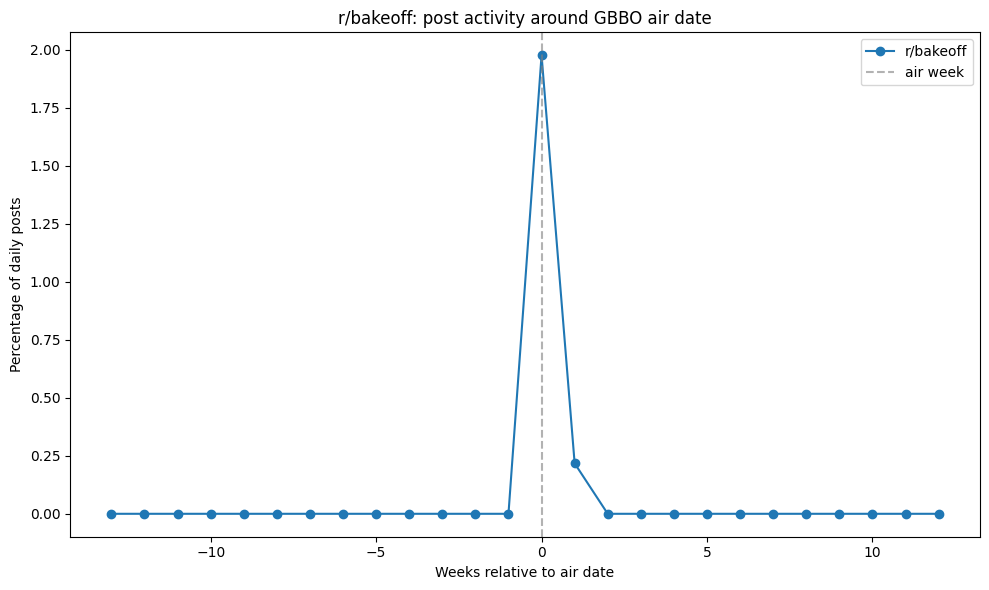

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bakeoff_weekly['week_bucket'], bakeoff_weekly['share']*100, marker='o', label='r/bakeoff')

ax.axvline(0, color='gray', linestyle='--', alpha=0.6, label='air week')

ax.set_xlabel('Weeks relative to air date')
ax.set_ylabel('Percentage of daily posts')
ax.set_title('r/bakeoff: post activity around GBBO air date')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#merge to add ch allenge scores


technical_challenge_score = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/TechnicalBakes.csv')
technical_full_with_scores = pd.merge(technical_full, technical_challenge_score, on='Technical', how='left') 

In [24]:
technical_full_with_scores = technical_full_with_scores[technical_full_with_scores['challenge level numeric'].notna()]

In [29]:
#get the ones that were actually baked and have challenge scores
baked_with_scores = technical_full_with_scores[technical_full_with_scores['post_count'] > 0]
baked_with_scores.sort_values(by='post_count', ascending=False)

,reddit_post_date,Technical,post_count,Airdate_x,date,count,share,days_since_air,Airdate_y,Season,Episode,Theme,Signature,Signature Time (min),Technical Time (min),Showstopper,Showstopper Time (min),challenge level numeric
3154,2016-09-01,viennese whirls,1,2016-08-31,2016-09-01,4,0.250000,1,8/31/2016,7,2,biscuit,24 iced biscuits,150.0,90.0,gingerbread 3d scene,240.0,2.0
3211,2016-09-04,viennese whirls,1,2016-08-31,2016-09-04,5,0.200000,4,8/31/2016,7,2,biscuit,24 iced biscuits,150.0,90.0,gingerbread 3d scene,240.0,2.0
4107,2016-10-24,fondant fancies,1,2012-10-16,2016-10-24,3,0.333333,1469,10/16/2012,3,10,final,pithivier,150.0,150.0,chiffon cake,240.0,2.0
13248,2019-05-18,queen of puddings,1,2012-09-18,2019-05-18,1,1.000000,2433,9/18/2012,3,6,pudding,2 sponge puddings,120.0,NaN,strudel,210.0,2.0
14807,2019-09-17,chocolate teacakes,1,2012-10-02,2019-09-17,11,0.090909,2541,10/2/2012,3,8,biscuit,48 crackers,120.0,120.0,gingerbread structure,240.0,2.0
19957,2020-08-16,æbleskiver,1,2018-10-16,2020-08-16,2,0.500000,670,10/16/2018,9,8,danish,2 smørrebrød,210.0,60.0,kagemand/kagekone,270.0,1.0
20414,2020-09-13,lemon meringue pie,1,2022-10-11,2020-09-13,3,0.333333,-758,10/11/2022,13,5,desserts,8 steamed puddings,120.0,120.0,hidden surprise mousse dessert,270.0,2.0
20700,2020-09-28,miniature pineapple upside-down cakes,1,2020-09-22,2020-09-28,11,0.090909,6,9/22/2020,11,1,cake,battenberg cake,120.0,90.0,celebrity hero cake bust,240.0,2.0
25834,2021-08-07,red velvet cake,1,2022-09-13,2021-08-07,3,0.333333,-402,9/13/2022,13,1,cake,12 mini sandwich cakes,120.0,120.0,3d cake home,240.0,2.0
26728,2021-09-27,malt loaf,1,2021-09-21,2021-09-27,6,0.166667,6,9/21/2021,12,1,cake,12 mini swill rolls,120.0,120.0,anti-gravity illusion cake,240.0,1.0


In [33]:
technical_challenge_score['challenge level numeric'].value_counts()

challenge level numeric
2.0    45
1.0    13
3.0    10
Name: count, dtype: int64

In [34]:
technical_full_with_scores['challenge level numeric'].value_counts()

challenge level numeric
2.0    27115
1.0     4930
Name: count, dtype: int64

In [35]:
baked_with_scores['challenge level numeric'].value_counts()

challenge level numeric
2.0    12
1.0     2
Name: count, dtype: int64

In [39]:
from scipy import stats

n_posted = 14  # adjust to your actual count
n_posted_score2 = 12  # adjust if not literally all 20
base_rate_score2 = 45 / 68

p_value = stats.binomtest(n_posted_score2, n_posted, base_rate_score2, alternative='greater').pvalue
print(p_value)

0.098632669229924


Given the 0.98 p-value, I can probably say there's a numerical tilt towards moderate-difficulty but its not statistically distinguishable from what I'd see by chance.